# Lens Subtraction Demo

This notebook demonstrates the `mejiro.analysis.lens_subtraction` module, which fits and subtracts a Sersic profile from the central lensing galaxy in a strong lens image. This is useful for revealing the lensed source arcs hidden beneath the bright lens light.

The module provides three functions:
- **`fit_sersic`** — fits a Sersic elliptical profile to a 2D image using L-BFGS-B optimization
- **`subtract_lens`** — high-level wrapper that fits and subtracts the lens light from an `Exposure` object
- **`plot_lens_subtraction`** — 3-panel visualization of original, model, and residual

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Util import util as lenstronomy_util

from mejiro.analysis.lens_subtraction import fit_sersic, subtract_lens, plot_lens_subtraction

## 1. Round-trip test: recovering known Sersic parameters with `fit_sersic`

First, we generate a synthetic Sersic image with known parameters and verify that `fit_sersic` can recover them. This mirrors `test_fit_sersic_roundtrip` in the test suite.

In [2]:
# ground-truth Sersic parameters
num_pix = 51
pixel_scale = 0.11  # arcsec/pix (Roman-like)

true_kwargs = {
    'amp': 500.0,
    'R_sersic': 0.4,
    'n_sersic': 4.0,
    'center_x': 0.05,
    'center_y': -0.03,
    'e1': 0.02,
    'e2': 0.04,
}

# generate the ground-truth image using lenstronomy
x, y, *_ = lenstronomy_util.make_grid_with_coordtransform(
    numPix=num_pix, deltapix=pixel_scale, subgrid_res=1,
    left_lower=False, inverse=False)
light_model = LightModel(['SERSIC_ELLIPSE'])
true_image = light_model.surface_brightness(x, y, [true_kwargs]).reshape(num_pix, num_pix)

print(f'Image shape: {true_image.shape}')
print(f'Peak flux:   {true_image.max():.1f}')
print(f'Total flux:  {true_image.sum():.1f}')

Image shape: (51, 51)
Peak flux:   9071.2
Total flux:  134629.1


### Visualize the ground-truth Sersic image

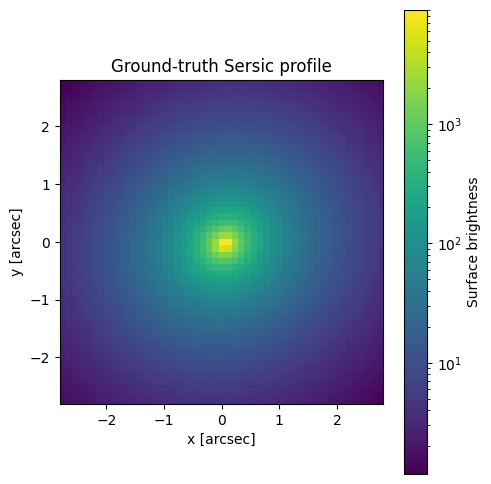

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
extent = np.array([-num_pix/2, num_pix/2, -num_pix/2, num_pix/2]) * pixel_scale
im = ax.imshow(true_image, origin='lower', cmap='viridis', norm=LogNorm(), extent=extent)
ax.set_xlabel('x [arcsec]')
ax.set_ylabel('y [arcsec]')
ax.set_title('Ground-truth Sersic profile')
fig.colorbar(im, ax=ax, label='Surface brightness')
plt.tight_layout()

### Fit the image and compare recovered parameters

In [4]:
# run the fitter (no initial guess — uses defaults)
best_fit, model_image, result = fit_sersic(true_image, pixel_scale)

print(f'Optimization converged: {result.success}')
print(f'Cost function value:    {result.fun:.4e}\n')

# compare parameters
print(f'{"Parameter":<12} {"True":>10} {"Recovered":>10} {"Rel. Error":>10}')
print('-' * 45)
for key in ['amp', 'R_sersic', 'n_sersic', 'center_x', 'center_y', 'e1', 'e2']:
    true_val = true_kwargs[key]
    fit_val = best_fit[key]
    if abs(true_val) > 1e-6:
        rel_err = abs(fit_val - true_val) / abs(true_val)
        print(f'{key:<12} {true_val:>10.4f} {fit_val:>10.4f} {rel_err:>10.2%}')
    else:
        print(f'{key:<12} {true_val:>10.4f} {fit_val:>10.4f} {"N/A":>10}')

Optimization converged: True
Cost function value:    1.9255e-05

Parameter          True  Recovered Rel. Error
---------------------------------------------
amp            500.0000   500.0025      0.00%
R_sersic         0.4000     0.4000      0.00%
n_sersic         4.0000     4.0000      0.00%
center_x         0.0500     0.0500      0.00%
center_y        -0.0300    -0.0300      0.00%
e1               0.0200     0.0200      0.00%
e2               0.0400     0.0400      0.00%


### Visualize the round-trip fit: truth, model, and residual

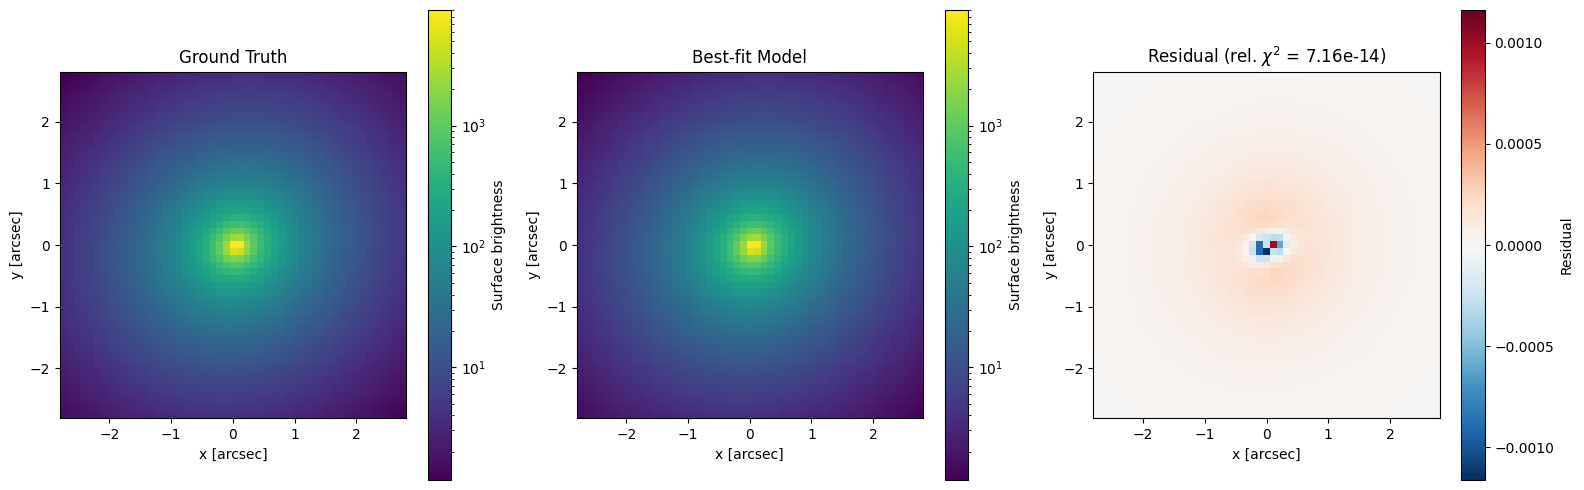

In [5]:
residual_rt = true_image - model_image
relative_residual = np.sum(residual_rt**2) / np.sum(true_image**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# truth
im0 = axes[0].imshow(true_image, origin='lower', cmap='viridis', norm=LogNorm(), extent=extent)
axes[0].set_title('Ground Truth')
fig.colorbar(im0, ax=axes[0], label='Surface brightness')

# best-fit model
im1 = axes[1].imshow(model_image, origin='lower', cmap='viridis', norm=LogNorm(), extent=extent)
axes[1].set_title('Best-fit Model')
fig.colorbar(im1, ax=axes[1], label='Surface brightness')

# residual
vmax = np.max(np.abs(residual_rt))
im2 = axes[2].imshow(residual_rt, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax, extent=extent)
axes[2].set_title(f'Residual (rel. $\\chi^2$ = {relative_residual:.2e})')
fig.colorbar(im2, ax=axes[2], label='Residual')

for ax in axes:
    ax.set_xlabel('x [arcsec]')
    ax.set_ylabel('y [arcsec]')

plt.tight_layout()

### Radial profile comparison

A 1D radial profile gives a clearer picture of how well the model fits the data.

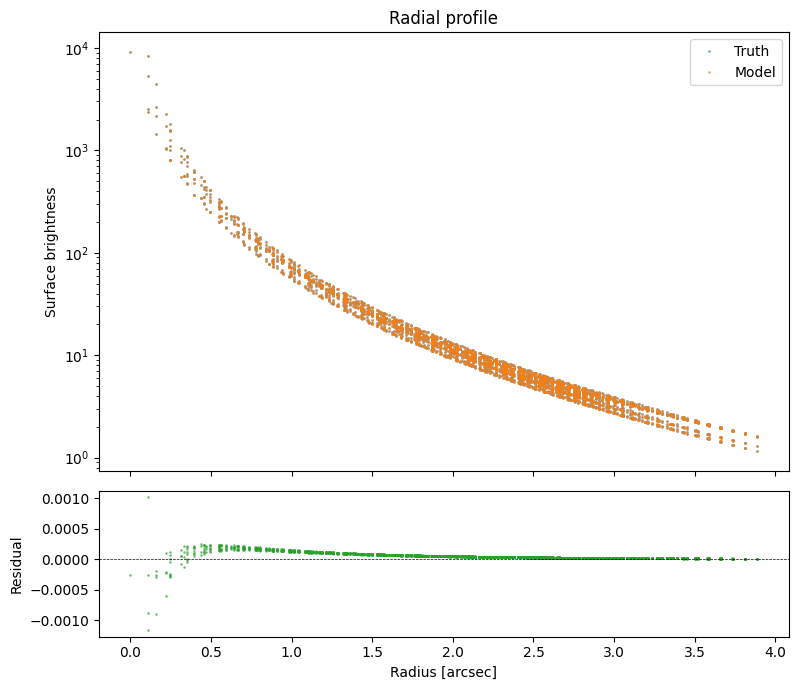

In [6]:
# compute radial profiles from center
cy, cx = num_pix // 2, num_pix // 2
yy, xx = np.mgrid[:num_pix, :num_pix]
r = np.sqrt((xx - cx)**2 + (yy - cy)**2) * pixel_scale  # in arcsec

r_flat = r.ravel()
sort_idx = np.argsort(r_flat)
r_sorted = r_flat[sort_idx]

true_sorted = true_image.ravel()[sort_idx]
model_sorted = model_image.ravel()[sort_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.semilogy(r_sorted, true_sorted, '.', ms=2, alpha=0.5, label='Truth')
ax1.semilogy(r_sorted, model_sorted, '.', ms=2, alpha=0.5, label='Model')
ax1.set_ylabel('Surface brightness')
ax1.legend()
ax1.set_title('Radial profile')

ax2.plot(r_sorted, true_sorted - model_sorted, '.', ms=2, alpha=0.5, color='C2')
ax2.axhline(0, color='k', ls='--', lw=0.5)
ax2.set_xlabel('Radius [arcsec]')
ax2.set_ylabel('Residual')

plt.tight_layout()

## 2. Lens subtraction on a realistic galaxy-galaxy lens

Now we test the full pipeline on a simulated strong lens `Exposure` using `subtract_lens`. This mirrors `test_subtract_lens_on_exposure` in the test suite.

In [7]:
import os
import mejiro
from mejiro.exposure import Exposure
from mejiro.synthetic_image import SyntheticImage
from mejiro.galaxy_galaxy import SampleGG
from mejiro.instruments.roman import Roman
from mejiro.engines.stpsf_engine import STPSFEngine

TEST_DATA_DIR = os.path.join(os.path.dirname(os.path.dirname(mejiro.__file__)), 'tests', 'test_data')

### Set up the strong lens system and generate a noiseless exposure

In [8]:
strong_lens = SampleGG()
band = 'F129'
detector = 'SCA01'
detector_position = (2048, 2048)

print(f'Lens redshift:   z = {strong_lens.z_lens:.4f}')
print(f'Source redshift:  z = {strong_lens.z_source:.4f}')
print(f'Lens light params: {strong_lens.kwargs_lens_light[0]}')

Lens redshift:   z = 0.2902
Source redshift:  z = 0.5877
Lens light params: {'R_sersic': 0.5300707454127908, 'center_x': -0.007876281728887604, 'center_y': 0.010633393703246008, 'e1': 0.023377277902774978, 'e2': 0.05349948216860632, 'magnitude': None, 'n_sersic': 4.0}


In [9]:
kwargs_psf = STPSFEngine.get_roman_psf_kwargs(
    band, detector, detector_position, oversample=5, num_pix=101,
    check_cache=True, psf_cache_dir=TEST_DATA_DIR, verbose=False)

synthetic_image = SyntheticImage(
    strong_lens=strong_lens,
    instrument=Roman(),
    band=band,
    fov_arcsec=5,
    instrument_params={'detector': detector, 'detector_position': detector_position},
    kwargs_numerics={},
    kwargs_psf=kwargs_psf,
    pieces=True,  # separate lens and source light
    verbose=False)

engine_params = {
    'sky_background': False,
    'detector_effects': False,
}
exposure = Exposure(
    synthetic_image,
    exposure_time=146,
    engine='galsim',
    engine_params=engine_params,
    verbose=False)

print(f'Exposure shape:  {exposure.exposure.shape}')
print(f'Pixel scale:     {synthetic_image.pixel_scale} arcsec/pix')
print(f'Peak counts:     {exposure.exposure.max():.1f}')

Exposure shape:  (47, 47)
Pixel scale:     0.11 arcsec/pix
Peak counts:     21213.0


### Visualize the exposure components

Since we set `pieces=True`, we can see the lens and source light separately.

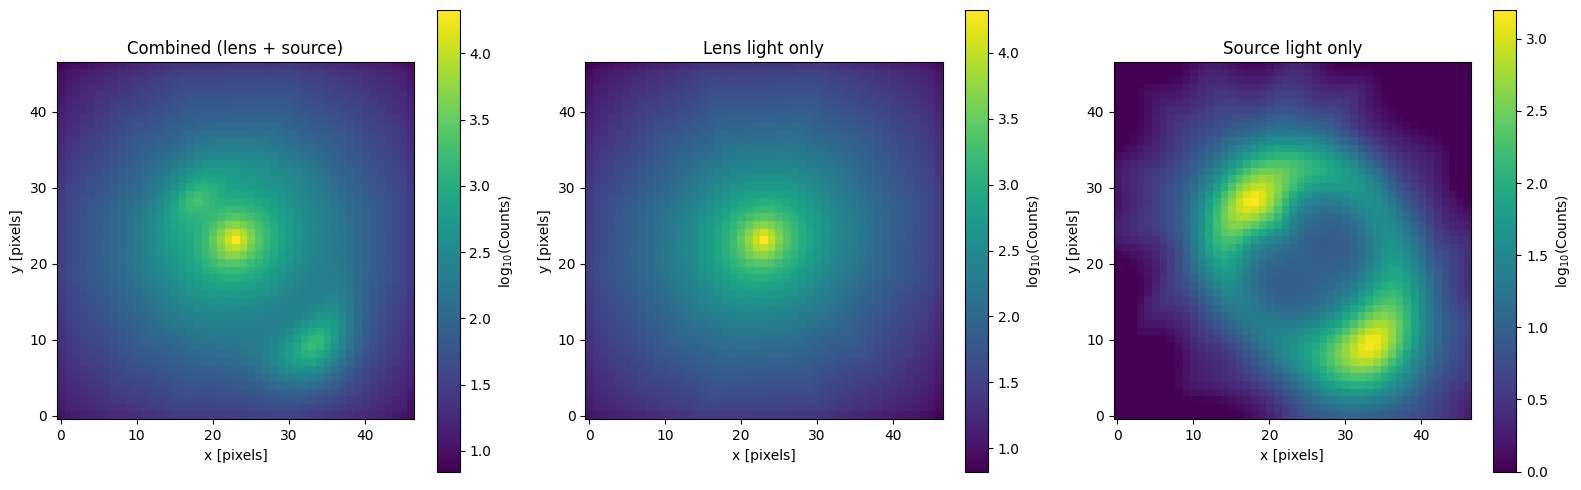

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    (exposure.exposure, 'Combined (lens + source)'),
    (exposure.lens_exposure, 'Lens light only'),
    (exposure.source_exposure, 'Source light only'),
]

for ax, (img, title) in zip(axes, panels):
    im = ax.imshow(np.log10(np.clip(img, 1, None)), origin='lower', cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')
    fig.colorbar(im, ax=ax, label=r'log$_{10}$(Counts)')

plt.tight_layout()

### Run `subtract_lens` and inspect results

In [11]:
residual, model, best_fit, fit_result = subtract_lens(exposure)

print(f'Optimization converged: {fit_result.success}')
print(f'\nBest-fit Sersic parameters:')
for key, val in best_fit.items():
    print(f'  {key:<12} = {val:.4f}')

# sanity checks (from the test suite)
original_peak = np.max(exposure.exposure)
residual_peak = np.max(np.abs(residual))
print(f'\nOriginal peak: {original_peak:.1f}')
print(f'Residual peak: {residual_peak:.1f}')
print(f'Peak reduced by {(1 - residual_peak / original_peak) * 100:.1f}%')

center = exposure.exposure.shape[0] // 2
hw = 5
central_original = np.sum(exposure.exposure[center-hw:center+hw, center-hw:center+hw])
central_residual = np.sum(np.abs(residual[center-hw:center+hw, center-hw:center+hw]))
print(f'\nCentral {2*hw}x{2*hw} px flux — original: {central_original:.1f}, residual: {central_residual:.1f}')

Optimization converged: True

Best-fit Sersic parameters:
  amp          = 1037.5959
  R_sersic     = 0.6388
  n_sersic     = 2.2398
  center_x     = -0.0282
  center_y     = 0.0151
  e1           = -0.0080
  e2           = -0.0024

Original peak: 21213.0
Residual peak: 2133.2
Peak reduced by 89.9%

Central 10x10 px flux — original: 279642.0, residual: 33879.6


### Visualize with `plot_lens_subtraction`

The module's built-in plotting function shows the original, model, and residual side by side.

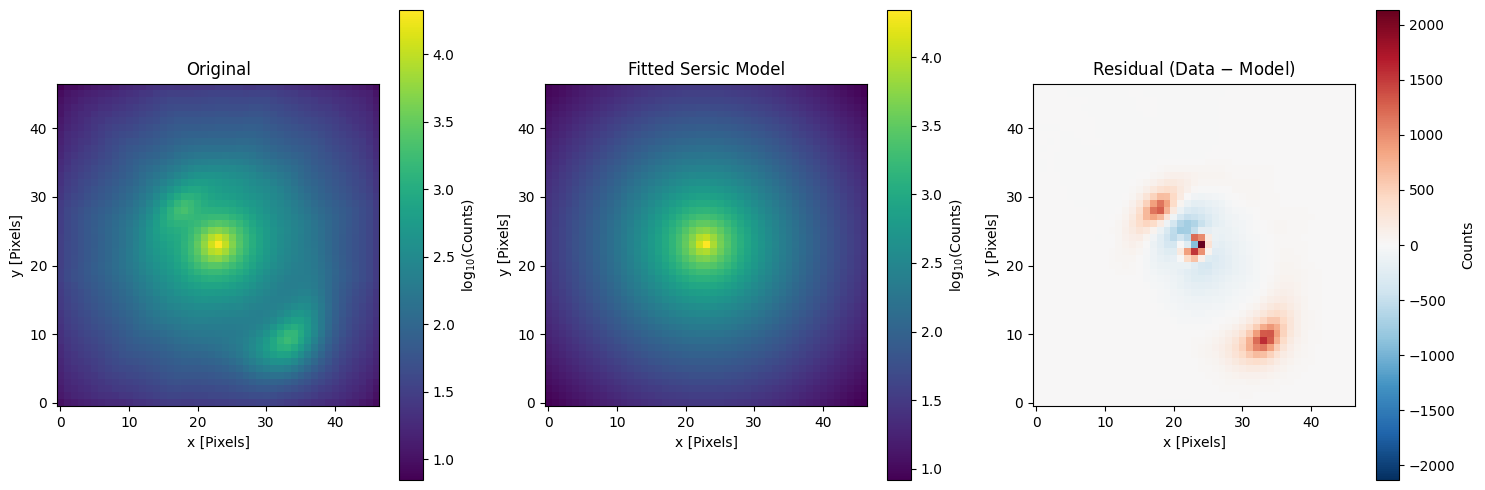

In [12]:
plot_lens_subtraction(exposure.exposure, model, residual)

### Compare the residual to the true source light

Since we generated the exposure with `pieces=True`, we can compare the lens-subtracted residual directly to the true source-only image. Ideally the residual should recover the lensed arcs.

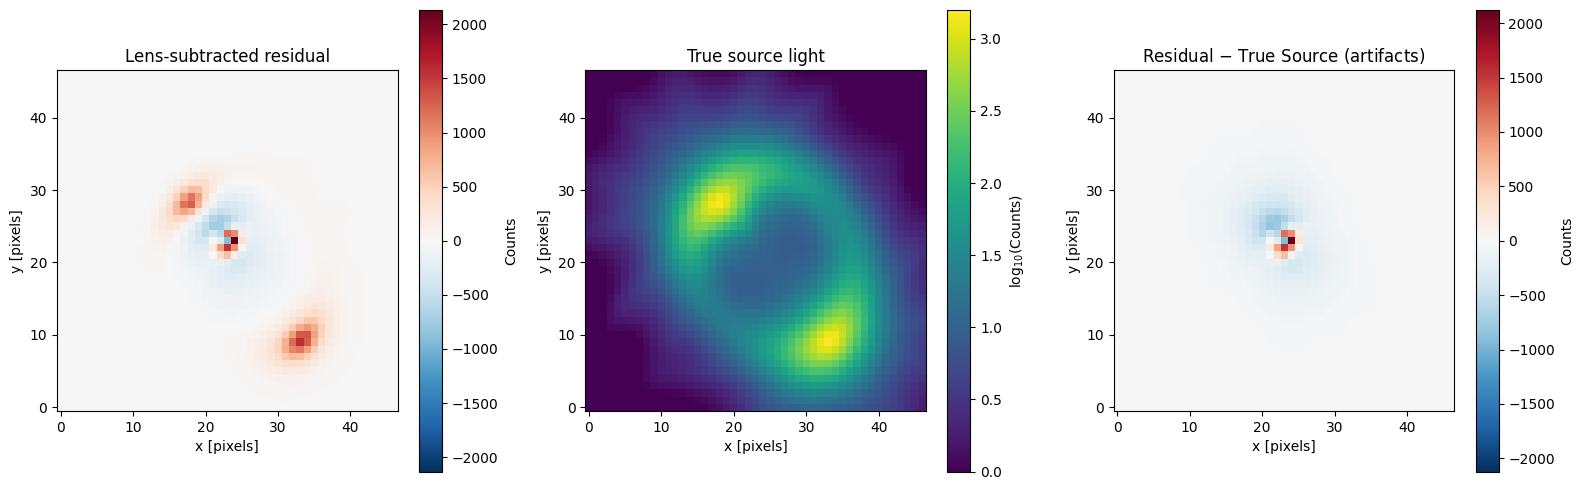

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# residual from lens subtraction
vmax = np.max(np.abs(residual))
im0 = axes[0].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[0].set_title('Lens-subtracted residual')
fig.colorbar(im0, ax=axes[0], label='Counts')

# true source light
im1 = axes[1].imshow(np.log10(np.clip(exposure.source_exposure, 1, None)),
                      origin='lower', cmap='viridis')
axes[1].set_title('True source light')
fig.colorbar(im1, ax=axes[1], label=r'log$_{10}$(Counts)')

# residual minus true source (subtraction artifacts)
artifact = residual - exposure.source_exposure
vmax_art = np.max(np.abs(artifact))
im2 = axes[2].imshow(artifact, origin='lower', cmap='RdBu_r', vmin=-vmax_art, vmax=vmax_art)
axes[2].set_title('Residual $-$ True Source (artifacts)')
fig.colorbar(im2, ax=axes[2], label='Counts')

for ax in axes:
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')

plt.tight_layout()

### Radial profile: original vs. model vs. source

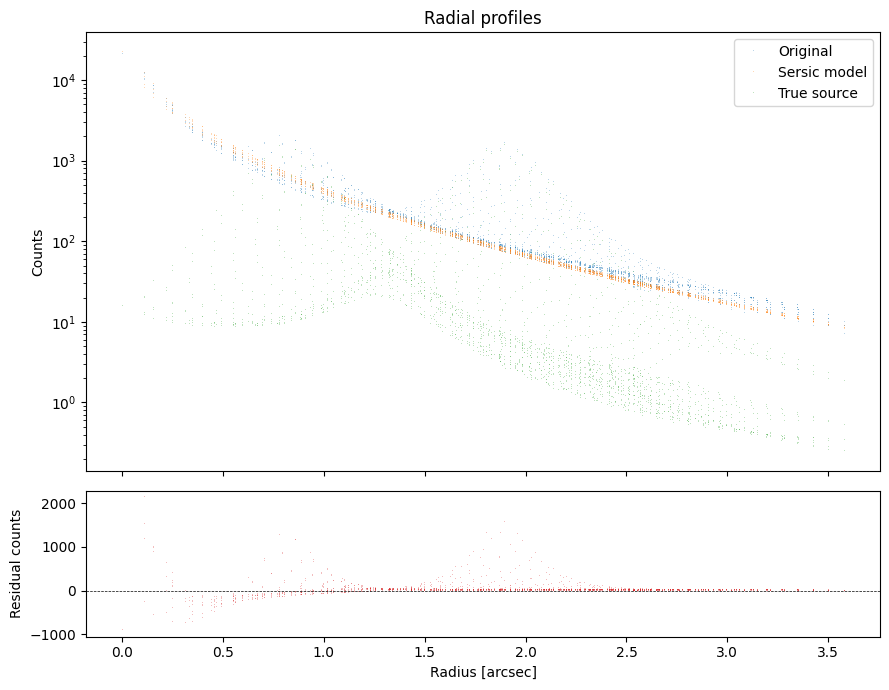

In [14]:
npix_exp = exposure.exposure.shape[0]
cy, cx = npix_exp // 2, npix_exp // 2
yy, xx = np.mgrid[:npix_exp, :npix_exp]
r_exp = np.sqrt((xx - cx)**2 + (yy - cy)**2) * synthetic_image.pixel_scale

r_flat = r_exp.ravel()
sort_idx = np.argsort(r_flat)
r_sorted = r_flat[sort_idx]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.semilogy(r_sorted, exposure.exposure.ravel()[sort_idx], ',', alpha=0.3, label='Original')
ax1.semilogy(r_sorted, model.ravel()[sort_idx], ',', alpha=0.3, label='Sersic model')
ax1.semilogy(r_sorted, np.clip(exposure.source_exposure.ravel()[sort_idx], 0.1, None),
             ',', alpha=0.3, label='True source')
ax1.set_ylabel('Counts')
ax1.legend(markerscale=10)
ax1.set_title('Radial profiles')

ax2.plot(r_sorted, residual.ravel()[sort_idx], ',', alpha=0.3, color='C3', label='Residual')
ax2.axhline(0, color='k', ls='--', lw=0.5)
ax2.set_xlabel('Radius [arcsec]')
ax2.set_ylabel('Residual counts')

plt.tight_layout()

## 3. Effect of providing initial guesses

`fit_sersic` can accept custom initial parameters. Here we compare the default initial guess to one seeded from the true lens light parameters (as `subtract_lens` does automatically).

In [15]:
# fit with default initial guess (no prior knowledge)
best_fit_default, model_default, result_default = fit_sersic(
    exposure.exposure, synthetic_image.pixel_scale)

# fit with informed initial guess from the strong lens model
lens_light_kwargs = strong_lens.kwargs_lens_light[0]
informed_kwargs = {
    'amp': np.max(exposure.exposure),
    'R_sersic': lens_light_kwargs.get('R_sersic', 0.5),
    'n_sersic': lens_light_kwargs.get('n_sersic', 4.0),
    'center_x': lens_light_kwargs.get('center_x', 0.0),
    'center_y': lens_light_kwargs.get('center_y', 0.0),
    'e1': lens_light_kwargs.get('e1', 0.0),
    'e2': lens_light_kwargs.get('e2', 0.0),
}
best_fit_informed, model_informed, result_informed = fit_sersic(
    exposure.exposure, synthetic_image.pixel_scale, initial_kwargs=informed_kwargs)

print(f'{"Parameter":<12} {"Default init":>14} {"Informed init":>14}')
print('-' * 42)
for key in best_fit_default:
    print(f'{key:<12} {best_fit_default[key]:>14.4f} {best_fit_informed[key]:>14.4f}')
print(f'\n{"Cost":<12} {result_default.fun:>14.2f} {result_informed.fun:>14.2f}')
print(f'{"Converged":<12} {str(result_default.success):>14} {str(result_informed.success):>14}')

Parameter      Default init  Informed init
------------------------------------------
amp               1037.6398      1037.5959
R_sersic             0.6388         0.6388
n_sersic             2.2398         2.2398
center_x            -0.0282        -0.0282
center_y             0.0151         0.0151
e1                  -0.0080        -0.0080
e2                  -0.0024        -0.0024

Cost            60186263.82    60186263.82
Converged              True           True


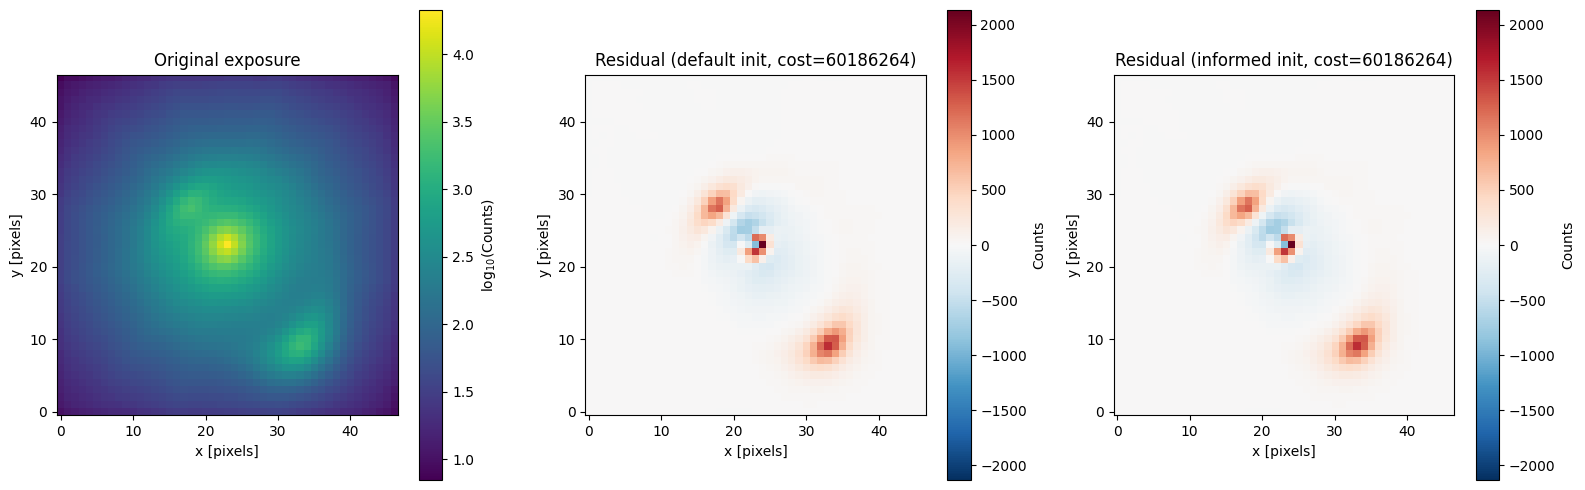

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

residual_default = exposure.exposure - model_default
residual_informed = exposure.exposure - model_informed

vmax = max(np.max(np.abs(residual_default)), np.max(np.abs(residual_informed)))

im0 = axes[0].imshow(np.log10(np.clip(exposure.exposure, 1, None)), origin='lower', cmap='viridis')
axes[0].set_title('Original exposure')
fig.colorbar(im0, ax=axes[0], label=r'log$_{10}$(Counts)')

im1 = axes[1].imshow(residual_default, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[1].set_title(f'Residual (default init, cost={result_default.fun:.0f})')
fig.colorbar(im1, ax=axes[1], label='Counts')

im2 = axes[2].imshow(residual_informed, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
axes[2].set_title(f'Residual (informed init, cost={result_informed.fun:.0f})')
fig.colorbar(im2, ax=axes[2], label='Counts')

for ax in axes:
    ax.set_xlabel('x [pixels]')
    ax.set_ylabel('y [pixels]')

plt.tight_layout()

## 4. Histogram of residual pixel values

A well-subtracted image should have a residual distribution centered near zero, with tails from the source arcs.

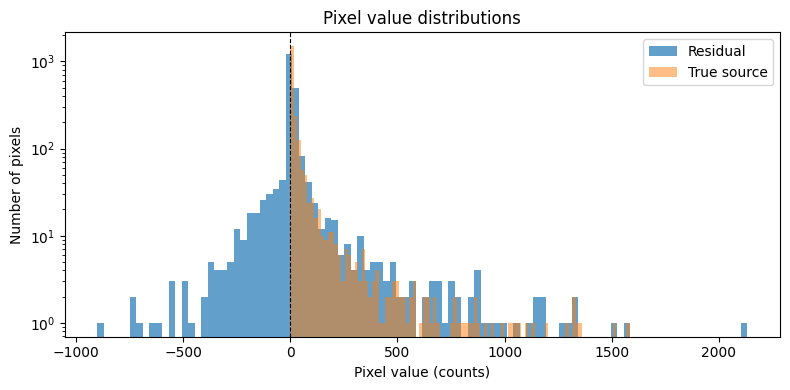

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(residual.ravel(), bins=100, alpha=0.7, label='Residual', color='C0')
ax.hist(exposure.source_exposure.ravel(), bins=100, alpha=0.5, label='True source', color='C1')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_xlabel('Pixel value (counts)')
ax.set_ylabel('Number of pixels')
ax.set_title('Pixel value distributions')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()